# 06 · Cálculo científico com SciPy
**GA033 · Módulo de introdução à programação científica**

O NumPy organiza os dados; a SciPy oferece algoritmos para operar com eles. Vamos resolver sistemas pequenos, representar uma matriz esparsa e aproximar integrais.

**Pré-requisitos:** funções Python, arrays, produto matricial e a ideia de integral definida. Execute na ordem; os exercícios não fornecem dados necessários às células posteriores.


## Objetivos

Ao final, você deverá conseguir:

- resolver $Au=b$ e calcular o resíduo;
- distinguir uma matriz densa de um array esparso;
- interpretar os dois números retornados por uma quadratura;
- comparar uma aproximação com uma resposta conhecida.

As matrizes serão fornecidas prontas. As aplicações ao MEF aparecerão como contexto, sem implementar um método completo.


In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

from scipy.linalg import solve
from scipy.sparse import csr_array, diags_array
from scipy.sparse.linalg import spsolve
from scipy.integrate import quad

print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)

NumPy: 2.5.3
SciPy: 1.18.1


## 1. Um sistema pequeno com resposta verificável

Considere
\[
\begin{bmatrix}3&-1\\-1&2\end{bmatrix}u=
\begin{bmatrix}1\\3\end{bmatrix}.
\]

A solução é $u=(1,2)^T$. Usaremos **scipy.linalg.solve**; para este exemplo, **numpy.linalg.solve** também seria adequado. Em ambos os casos, não precisamos construir a inversa.

A chamada **np.testing.assert_allclose** verifica a resposta: não imprime nada quando a comparação passa e gera um erro quando a diferença excede as tolerâncias.


In [2]:
A = np.array([[3.0, -1.0], [-1.0, 2.0]])
b = np.array([1.0, 3.0])
u = solve(A, b)

print("Solução:", u)
np.testing.assert_allclose(u, [1.0, 2.0], atol=1e-12)

Solução: [1. 2.]


### O solucionador terminou. Como conferir?

O resíduo é $r=Au-b$. Sua norma deve ser pequena neste problema. Também podemos comparar com a solução conhecida.

Um resíduo pequeno verifica as equações; em problemas mal condicionados, isso sozinho não garante uma solução precisa. Aqui usamos as duas verificações.


In [3]:
r = A @ u - b
erro = np.linalg.norm(u - np.array([1.0, 2.0]))

print("Resíduo:", r)
print("Norma do resíduo:", np.linalg.norm(r))
print("Erro em relação à solução conhecida:", erro)

Resíduo: [8.8817842e-16 4.4408921e-16]
Norma do resíduo: 9.930136612989092e-16
Erro em relação à solução conhecida: 6.280369834735101e-16


## 2. Quando a maioria das entradas é zero

Uma matriz densa armazena todas as posições. Um array esparso armazena valores e informações sobre suas posições. Ele é útil quando existem muitos zeros estruturais.

Começaremos com **csr_array**, no formato CSR (*Compressed Sparse Row*). A matriz é pequena para podermos inspecioná-la; para uma matriz grande, convertê-la inteira com **toarray()** pode consumir muita memória.


In [4]:
A_pequena = np.array(
    [
        [2.0, -1.0, 0.0],
        [-1.0, 2.0, -1.0],
        [0.0, -1.0, 2.0],
    ]
)
A_csr = csr_array(A_pequena)

print("Formato:", A_csr.format)
print("shape:", A_csr.shape)
print("Entradas armazenadas:", A_csr.nnz)
print("Representação densa, apenas para esta matriz pequena:\n", A_csr.toarray())

Formato: csr
shape: (3, 3)
Entradas armazenadas: 7
Representação densa, apenas para esta matriz pequena:
 [[ 2. -1.  0.]
 [-1.  2. -1.]
 [ 0. -1.  2.]]


**nnz** conta entradas armazenadas: elas podem incluir zeros explícitos. Neste exemplo, são exatamente as sete entradas não nulas.

Para os arrays esparsos usados aqui, **@** faz o produto matricial e **\*** faz o produto elemento a elemento. Isso mantém a mesma distinção que estudamos com ndarray.


### Construir diretamente pelas diagonais

Uma matriz tridiagonal tem entradas apenas na diagonal principal e nas duas diagonais vizinhas. **diags_array** permite fornecer essas três diagonais.

Os deslocamentos **-1, 0, 1** indicam, respectivamente, a diagonal inferior, a principal e a superior. Especificamos tipo real e formato CSR explicitamente.


In [5]:
n = 25
T = diags_array(
    [-np.ones(n - 1), 2.0 * np.ones(n), -np.ones(n - 1)],
    offsets=[-1, 0, 1],
    shape=(n, n),
    format="csr",
    dtype=float,
)

print("shape:", T.shape)
print("Entradas armazenadas:", T.nnz, "de", n * n, "posições")
print(f"Fração de posições armazenadas: {T.nnz / (n * n):.1%}")

shape: (25, 25)
Entradas armazenadas: 73 de 625 posições
Fração de posições armazenadas: 11.7%


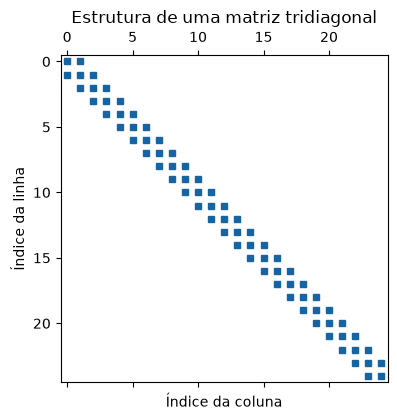

In [6]:
fig, ax = plt.subplots(figsize=(5.0, 4.3))
ax.spy(T, markersize=4, color="#1764a3")
ax.set(
    title="Estrutura de uma matriz tridiagonal",
    xlabel="Índice da coluna",
    ylabel="Índice da linha",
)
fig.tight_layout()
plt.show()
plt.close(fig)

### Resolver sem tornar a matriz densa

Vamos construir um teste cujo resultado já conhecemos: escolhemos $u_{\mathrm{ref}}$, calculamos $b=Tu_{\mathrm{ref}}$ e pedimos ao solucionador que recupere esse vetor.

Essa construção serve para **verificar o cálculo algébrico**. Em uma aplicação real, o lado direito vem dos dados do problema.


In [7]:
u_referencia = np.linspace(0.1, 1.0, n)
b_esparso = T @ u_referencia

u_esparso = spsolve(T, b_esparso)
residuo_esparso = T @ u_esparso - b_esparso

print("Primeiras componentes:", np.round(u_esparso[:5], 4))
print("Erro máximo:", np.max(np.abs(u_esparso - u_referencia)))
print("Norma do resíduo:", np.linalg.norm(residuo_esparso))
np.testing.assert_allclose(u_esparso, u_referencia, rtol=1e-12, atol=1e-12)

Primeiras componentes: [0.1    0.1375 0.175  0.2125 0.25  ]
Erro máximo: 1.887379141862766e-15
Norma do resíduo: 3.065703529144609e-16


No MEF, funções de base com suporte local frequentemente produzem matrizes esparsas: muitos pares de funções não interagem. A ideia de armazenar e resolver um sistema esparso será útil mais adiante.

O tamanho pequeno deste exemplo permite conferir o resultado. Não o use como evidência de ganho de velocidade: formatos esparsos também têm custos de organização e nem sempre compensam em problemas pequenos.


In [8]:
bytes_csr = T.data.nbytes + T.indices.nbytes + T.indptr.nbytes
bytes_denso = n * n * np.dtype(float).itemsize

print("Bytes dos três buffers CSR:", bytes_csr)
print("Bytes dos valores em formato denso:", bytes_denso)

Bytes dos três buffers CSR: 980
Bytes dos valores em formato denso: 5000


Essa comparação contabiliza os buffers principais, não toda a memória dos objetos Python nem a memória usada durante a fatoração. O solucionador pode criar entradas adicionais ao fatorar a matriz.


## 3. Quadratura: aproximar uma integral

Queremos
\[
I=\int_0^\pi \sin(x)\,dx=2.
\]

**quad** recebe uma função e os limites de integração. Ela retorna uma aproximação da integral e uma **estimativa do erro absoluto**. A função deve poder ser avaliada nos pontos escolhidos pelo algoritmo.


In [9]:
integral, erro_estimado = quad(np.sin, 0.0, np.pi, epsabs=1e-10, epsrel=1e-10)
erro_observado = abs(integral - 2.0)

print(f"Integral calculada: {integral:.15f}")
print(f"Erro absoluto estimado: {erro_estimado:.3e}")
print(f"Erro contra a integral exata: {erro_observado:.3e}")
np.testing.assert_allclose(integral, 2.0, atol=1e-12, rtol=0.0)

Integral calculada: 2.000000000000000
Erro absoluto estimado: 2.220e-14
Erro contra a integral exata: 0.000e+00


A estimativa usa informações obtidas durante a quadratura. Ela **não é uma garantia matemática geral** de que o erro real seja menor que o valor retornado.

Neste exemplo, conhecemos a integral exata e podemos comparar. Em aplicações, observe as tolerâncias, as hipóteses sobre a função e eventuais avisos de convergência.


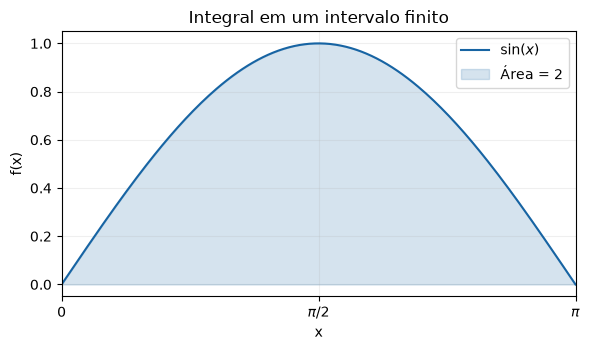

In [10]:
x_plot = np.linspace(0.0, np.pi, 200)
y_plot = np.sin(x_plot)

fig, ax = plt.subplots(figsize=(6.0, 3.6))
ax.plot(x_plot, y_plot, color="#1764a3", label=r"$\sin(x)$")
ax.fill_between(x_plot, 0.0, y_plot, color="#1764a3", alpha=0.18, label="Área = 2")
ax.set(
    xlabel="x", ylabel="f(x)", title="Integral em um intervalo finito", xlim=(0, np.pi)
)
ax.set_xticks([0, np.pi / 2, np.pi], ["0", r"$\pi/2$", r"$\pi$"])
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
plt.show()
plt.close(fig)

### Uma função com parâmetro

Para $a>0$,
\[
\int_0^1 e^{-ax}\,dx=\frac{1-e^{-a}}{a}.
\]

O argumento **args** permite fornecer valores adicionais à função. A vírgula em **(a,)** cria uma tupla com um único elemento.


In [11]:
def decaimento(x, a):
    return np.exp(-a * x)


a = 2.0
valor_parametrizado, estimativa_parametrizada = quad(decaimento, 0.0, 1.0, args=(a,))
valor_exato = (1.0 - np.exp(-a)) / a

print("Integral numérica:", valor_parametrizado)
print("Integral exata:", valor_exato)
print("Diferença:", abs(valor_parametrizado - valor_exato))

Integral numérica:

 0.43233235838169365
Integral exata: 0.43233235838169365
Diferença: 0.0


### Uma ligação com elementos finitos

No intervalo de referência $[0,1]$, as funções lineares $N_0(x)=1-x$ e $N_1(x)=x$ aparecem em elementos de Lagrange. Integrais de produtos dessas funções podem compor matrizes.

Vamos verificar somente uma integral:
\[
\int_0^1 N_0(x)N_1(x)\,dx
=\int_0^1(x-x^2)\,dx=\frac16.
\]


In [12]:
def produto_funcoes_lineares(x):
    return (1.0 - x) * x


valor_local, estimativa_local = quad(produto_funcoes_lineares, 0.0, 1.0)
print("Integral:", valor_local)
print("Valor esperado:", 1.0 / 6.0)
np.testing.assert_allclose(valor_local, 1.0 / 6.0, rtol=0.0, atol=1e-14)

Integral: 0.16666666666666666
Valor esperado: 0.16666666666666666


## Exercício 1 · Denso e esparso, mesmo sistema

Converta **A_ex1** para CSR, resolva com **spsolve** e compare com **solve**. Calcule o resíduo da solução esparsa. O objetivo é comparar respostas; não medir desempenho.


In [13]:
A_ex1 = np.array([[4.0, -1.0, 0.0], [-1.0, 4.0, -1.0], [0.0, -1.0, 4.0]])
b_ex1 = np.array([3.0, 2.0, 3.0])

u_denso_ex1 = solve(A_ex1, b_ex1)
u_csr_ex1 = None  # Converta A_ex1 com csr_array e resolva com spsolve.
print("Solução densa:", u_denso_ex1)
print("Sua solução esparsa:", u_csr_ex1)

Solução densa: [1. 1. 1.]
Sua solução esparsa: None


<details>
<summary>Conferir uma solução do exercício 1</summary>

~~~python
import numpy as np
from scipy.linalg import solve
from scipy.sparse import csr_array
from scipy.sparse.linalg import spsolve

A = np.array([[4.0, -1.0, 0.0], [-1.0, 4.0, -1.0], [0.0, -1.0, 4.0]])
b = np.array([3.0, 2.0, 3.0])
A_csr = csr_array(A)
u_denso = solve(A, b)
u_csr = spsolve(A_csr, b)

np.testing.assert_allclose(u_csr, u_denso, atol=1e-12)
np.testing.assert_allclose(u_csr, np.ones(3), atol=1e-12)
print("Norma do resíduo:", np.linalg.norm(A_csr @ u_csr - b))
~~~

O sistema tem solução $(1,1,1)^T$, o que permite uma terceira conferência.

</details>


## Exercício 2 · Integral com resposta exata

Calcule $\int_0^1 x^3\,dx$ com **quad**. Imprima separadamente o valor, o erro estimado e a diferença para $1/4$. Explique por que os dois últimos números não são a mesma informação.


In [14]:
def cubo_ex2(x):
    return x**3


resultado_ex2 = None  # Substitua por quad(cubo_ex2, ...).
if resultado_ex2 is None:
    print("Preencha resultado_ex2 para inspecionar os dois retornos.")
else:
    valor_ex2, estimativa_ex2 = resultado_ex2
    print("Valor:", valor_ex2)
    print("Estimativa:", estimativa_ex2)
    print("Erro contra a resposta exata:", abs(valor_ex2 - 0.25))

Preencha resultado_ex2 para inspecionar os dois retornos.


<details>
<summary>Conferir uma solução do exercício 2</summary>

~~~python
from scipy.integrate import quad

def cubo(x):
    return x**3

valor, estimativa = quad(cubo, 0.0, 1.0)
print(valor)
print(estimativa)
print(abs(valor - 0.25))
assert abs(valor - 0.25) < 1e-12
~~~

A estimativa vem do algoritmo; a última diferença usa uma resposta exata externa ao algoritmo. Não confunda uma estimativa numérica com um limite rigorosamente garantido.

</details>


## Exercício 3 · Conferir uma construção por diagonais

Construa uma matriz $5\times5$ com diagonal principal igual a 3 e diagonais vizinhas iguais a $-1$. Use o vetor de referência $(1,1,1,1,1)^T$ para produzir $b$.

Resolva o sistema, confira a resposta e conte as entradas armazenadas. Por que são $5+4+4=13$?


In [15]:
n_ex3 = 5
u_ref_ex3 = np.ones(n_ex3)
T_ex3 = None  # Use diags_array com offsets=[-1, 0, 1].

if T_ex3 is None:
    print("Construa T_ex3 para completar o teste.")
else:
    b_ex3 = T_ex3 @ u_ref_ex3
    u_ex3 = spsolve(T_ex3, b_ex3)
    print("Entradas armazenadas:", T_ex3.nnz)
    print("Erro máximo:", np.max(np.abs(u_ex3 - u_ref_ex3)))

Construa T_ex3 para completar o teste.


<details>
<summary>Conferir uma solução do exercício 3</summary>

~~~python
import numpy as np
from scipy.sparse import diags_array
from scipy.sparse.linalg import spsolve

n = 5
T = diags_array(
    [-np.ones(n - 1), 3.0 * np.ones(n), -np.ones(n - 1)],
    offsets=[-1, 0, 1], format="csr", dtype=float,
)
u_ref = np.ones(n)
b = T @ u_ref
u = spsolve(T, b)
assert T.nnz == 13
np.testing.assert_allclose(u, u_ref, atol=1e-12)
print("b:", b)  # [2., 1., 1., 1., 2.]
print("Norma do resíduo:", np.linalg.norm(T @ u - b))
~~~

As diagonais vizinhas têm uma entrada a menos que a principal.

</details>


## O que conferir em um cálculo científico

**Sistema linear:** dimensões, estrutura, resíduo e, quando disponível, comparação com resposta conhecida.

**Integral:** domínio, função, tolerâncias, estimativa retornada e uma referência independente quando possível.

Uma rotina retornar um número é o começo da interpretação. Escolha a verificação de acordo com o problema.


## Referências e autoria

A seleção de temas retoma ideias do [curso NumPy/SciPy de Diego Volpatto](https://github.com/volpatto/numpy_scipy_course), com redação e exemplos novos para a GA033.

Documentação oficial: [solve](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.solve.html), [csr_array](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.csr_array.html), [diags_array](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.diags_array.html), [spsolve](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.spsolve.html) e [quad](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html).

**Autor:** Diego Tavares Volpatto. **Licença:** [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).


[← Caderno anterior](05-graficos-e-resultados.ipynb) · [Índice do curso](../README.md) · [Próximo caderno →](07-organizacao-e-dataclasses.ipynb)

Autor: Diego Tavares Volpatto · [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/deed.pt-br)